<a href="https://colab.research.google.com/github/k-2229/eng-ai-agents-public/blob/main/notebooks/assignments/topics/cnn-explainers/index.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install captum

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from datasets import load_dataset
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from captum.attr import IntegratedGradients, LayerGradCam
from captum.attr import visualization as viz

In [3]:
IMG_SIZE = 150
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class SmallConvNet(nn.Module):
    def __init__(self, dropout=True):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 128, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(128 * 7 * 7, 512),
            nn.ReLU(),
            nn.Linear(512, 1),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x).squeeze(1)

In [4]:
ds_dict = load_dataset("pantelism/cats-vs-dogs")

basic_tf = transforms.Compose([
    transforms.Resize((150,150)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])

class CatsDogsDataset(Dataset):
    def __init__(self, hf_dataset, transform):
        self.data = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        img = sample["image"].convert("RGB")
        label = sample["label"]
        return self.transform(img), label

test_dataset = CatsDogsDataset(ds_dict["test"], basic_tf)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False
)

In [5]:
model = SmallConvNet(dropout=True).to(DEVICE)
model.load_state_dict(
    torch.load("/content/cats_and_dogs_small.pth", map_location=DEVICE)
)

model.eval()

SmallConvNet(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=6272, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=1, bias=True)
  )
)

In [6]:
correct_examples = []
wrong_examples = []

model.eval()

with torch.no_grad():
    for img, label in test_loader:
        img = img.to(DEVICE)

        output = model(img)
        prob = torch.sigmoid(output).item()

        prediction = 1 if prob > 0.5 else 0

        if prediction == label.item() and len(correct_examples) < 3:
            correct_examples.append((img.cpu(), label.item(), prediction))

        elif prediction != label.item() and len(wrong_examples) < 1:
            wrong_examples.append((img.cpu(), label.item(), prediction))

        if len(correct_examples) == 3 and len(wrong_examples) == 1:
            break

print("Correct examples found:", len(correct_examples))
print("Wrong examples found:", len(wrong_examples))

Correct examples found: 3
Wrong examples found: 1


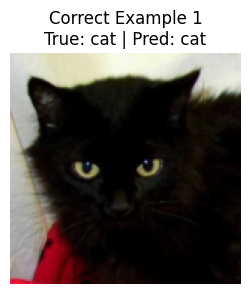

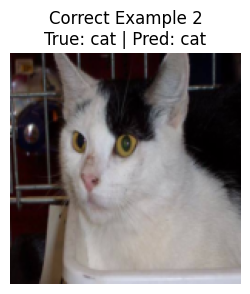

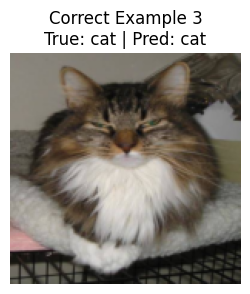

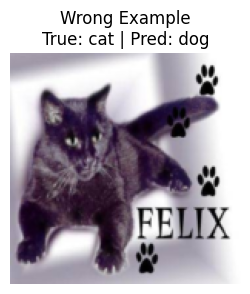

In [7]:
import matplotlib.pyplot as plt

def show_example(example, title):
    img, label, pred = example

    # Convert from normalized tensor back to image
    img = img.squeeze(0).permute(1, 2, 0)
    img = (img * 0.5) + 0.5   # undo normalization

    plt.figure(figsize=(3,3))
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"{title}\nTrue: {'dog' if label==1 else 'cat'} | "
        f"Pred: {'dog' if pred==1 else 'cat'}"
    )
    plt.show()


for i, ex in enumerate(correct_examples):
    show_example(ex, f"Correct Example {i+1}")

show_example(wrong_examples[0], "Wrong Example")

## Integrated Gradients Explanation

Integrated Gradients explains which pixels contributed to the CNN prediction. It compares the input image with a baseline image (usually a black image) and accumulates gradients along the path between the baseline and the original image. Pixels with larger attribution values have a stronger effect on the model's decision.

The baseline is important because it represents an uninformative input, allowing the method to measure how much each pixel changes the model output.

One limitation of Integrated Gradients is that the pixel-level explanations can sometimes be noisy and difficult to interpret.

In [27]:
from captum.attr import IntegratedGradients

# Create Integrated Gradients object
ig = IntegratedGradients(model)

# Choose the wrong example first
img, label, pred = wrong_examples[0]

img = img.to(DEVICE)

# Compute attribution
baseline = torch.zeros_like(img)

attributions = ig.attribute(
    img,
    baselines=baseline,
    target=None
)

print(attributions.shape)

torch.Size([1, 3, 150, 150])


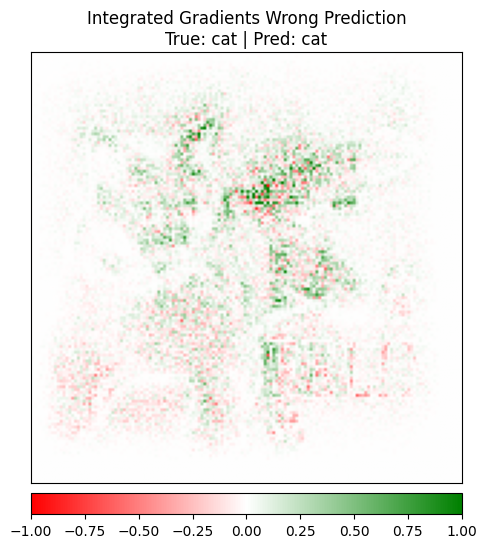

Caption: The model focused on features that resemble a dog more than the cat's distinguishing features, which may have caused the incorrect prediction.


In [34]:
from captum.attr import visualization as viz

attr = attributions.squeeze().cpu().detach().numpy()
attr = np.transpose(attr, (1,2,0))

original = img.squeeze().cpu().detach().numpy()
original = np.transpose(original, (1,2,0))

# Undo normalization
original = (original * 0.5) + 0.5
original = np.clip(original, 0, 1)

fig, ax = viz.visualize_image_attr(
    attr,
    original,
    method="heat_map",
    sign="all",
    show_colorbar=True,
    title=f"Integrated Gradients Wrong Prediction\nTrue: {'dog' if label==1 else 'cat'} | Pred: {'dog' if pred==1 else 'cat'}"
)

fig.savefig(
    "integrated_gradients_wrong_prediction.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
print("Caption: The model focused on features that resemble a dog more than the cat's distinguishing features, which may have caused the incorrect prediction.")

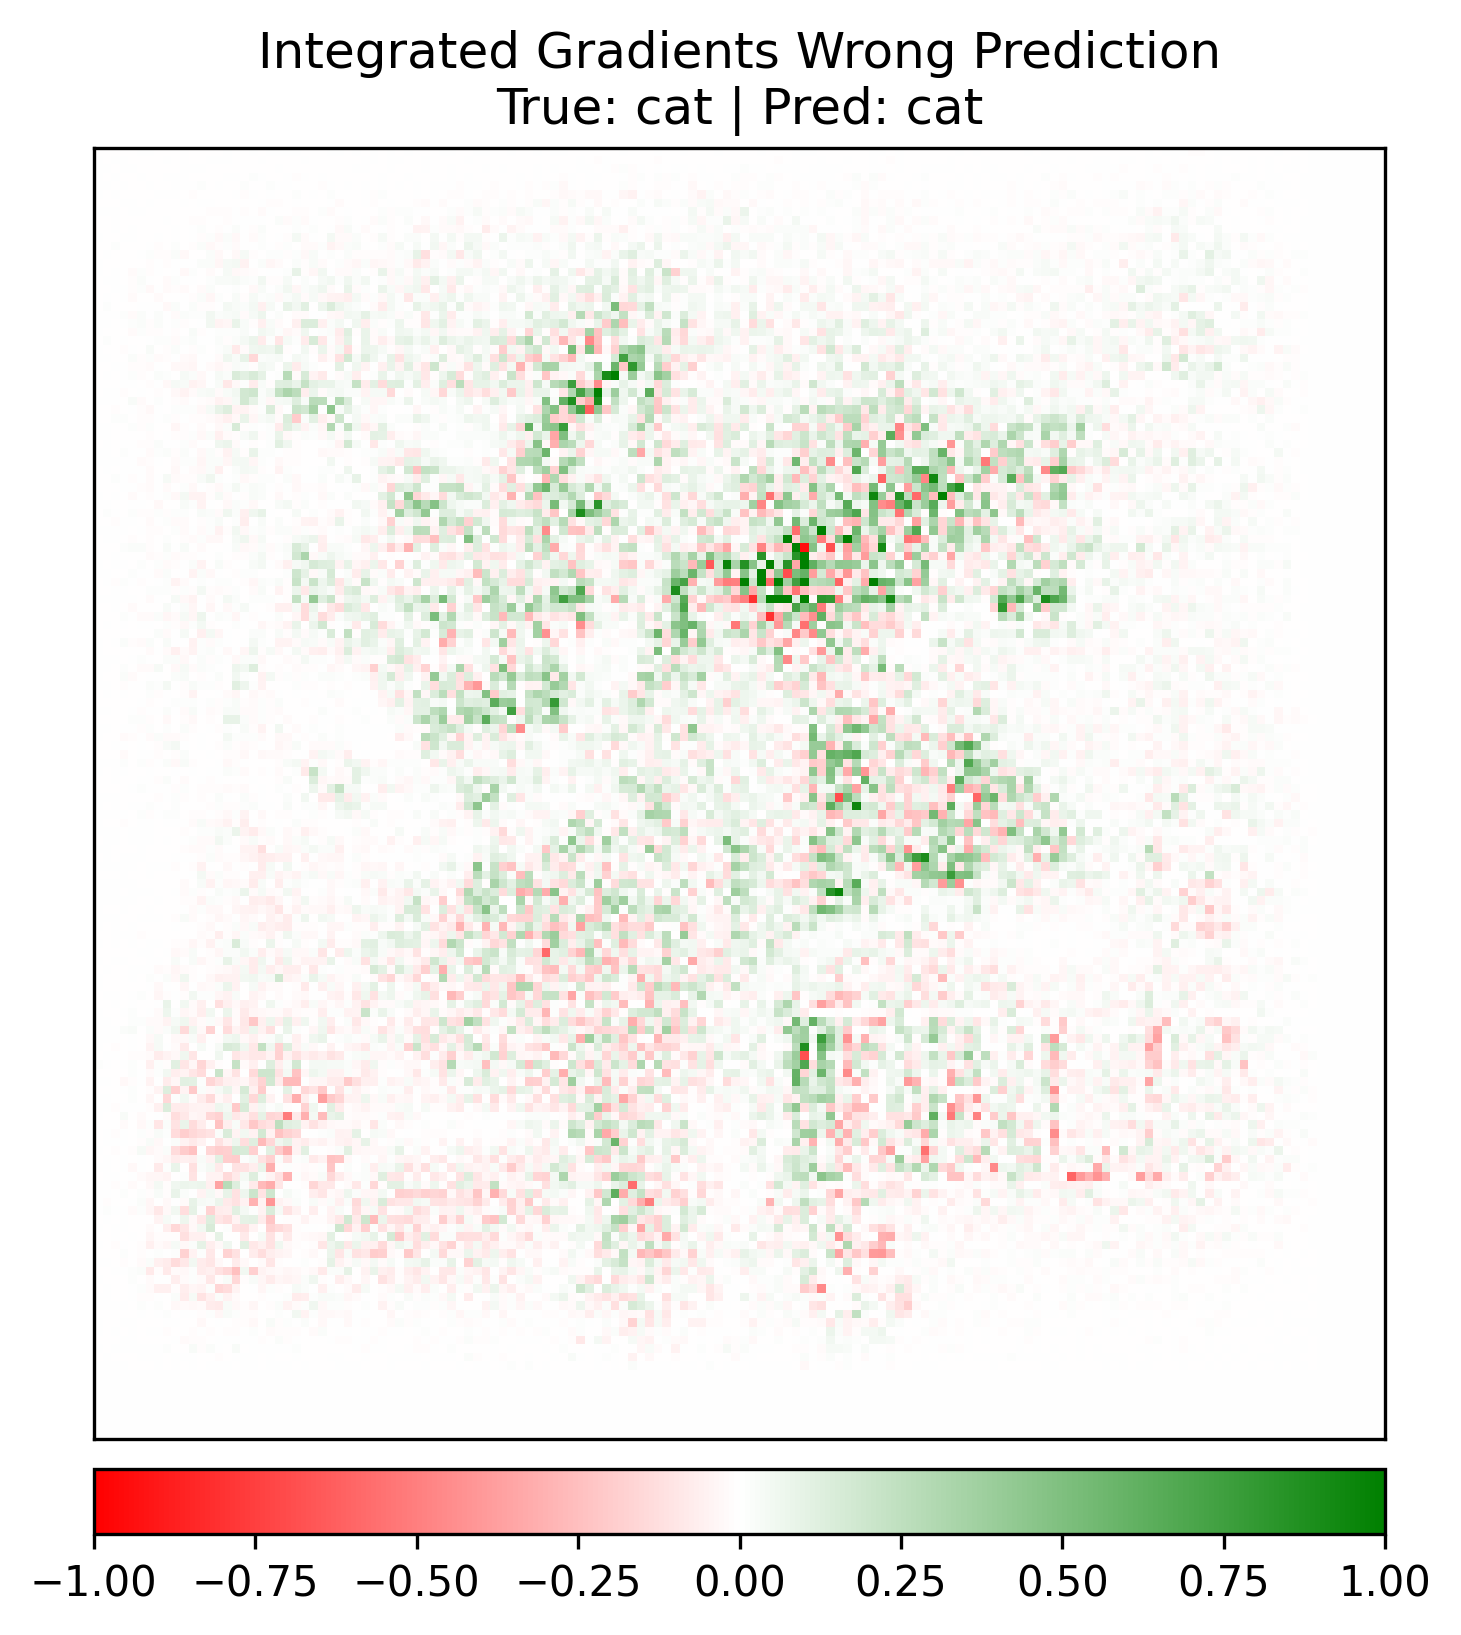

In [26]:
from IPython.display import Image

Image("integrated_gradients_wrong_prediction.png")

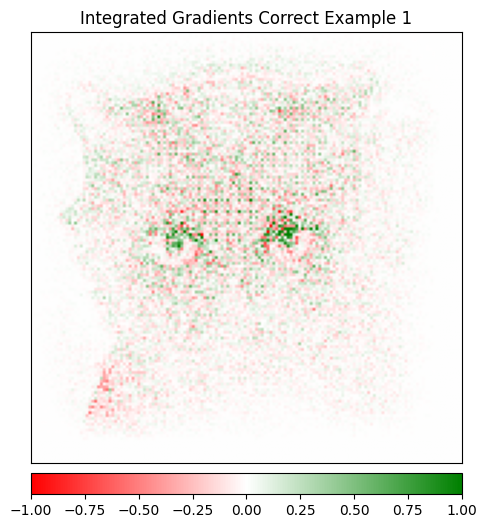

Caption: The model mainly focused on the animal's face and body, which were the most important regions for its prediction.


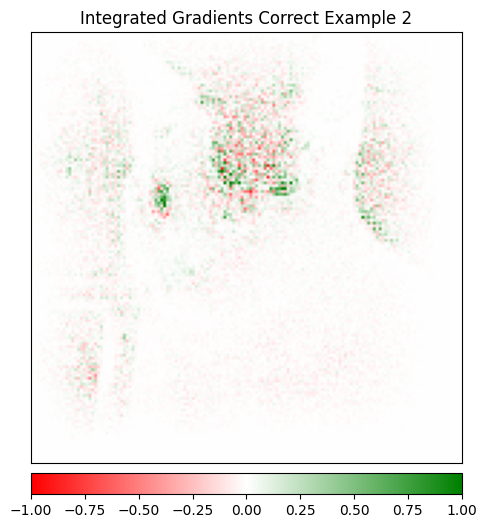

Caption: The model mainly focused on the animal's face and body, which were the most important regions for its prediction.


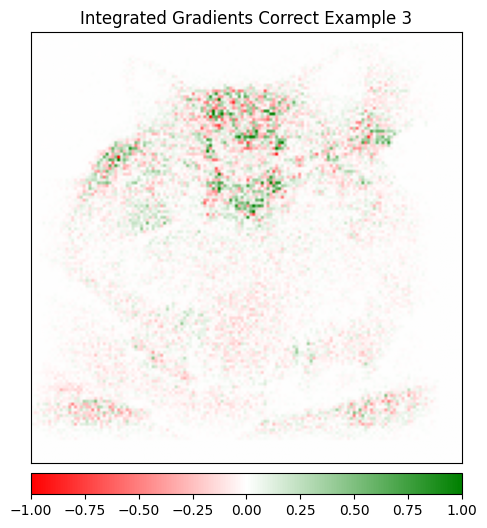

Caption: The model mainly focused on the animal's face and body, which were the most important regions for its prediction.


In [33]:
for i, example in enumerate(correct_examples):

    correct_img, correct_label, correct_pred = example
    correct_img = correct_img.to(DEVICE)

    baseline = torch.zeros_like(correct_img)

    correct_attr = ig.attribute(
        correct_img,
        baselines=baseline,
        target=None
    )

    attr = correct_attr.squeeze(0).detach().cpu().numpy()

    img_np = correct_img.detach().cpu().squeeze(0).permute(1,2,0).numpy()
    img_np = (img_np * 0.5) + 0.5
    img_np = np.clip(img_np,0,1)

    attr = np.transpose(attr,(1,2,0))

    viz.visualize_image_attr(
        attr,
        img_np,
        method="heat_map",
        sign="all",
        show_colorbar=True,
        title=f"Integrated Gradients Correct Example {i+1}"
    )

    plt.show()
    print("Caption: The model mainly focused on the animal's face and body, which were the most important regions for its prediction.")

## Grad-CAM Explanation

Grad-CAM highlights the image regions that influence the CNN prediction. It uses the gradients of the predicted class flowing into the feature maps of a convolutional layer. The final convolutional layer is used because it contains high-level visual features while keeping spatial information.

The target layer is the last convolutional layer of the CNN because it provides meaningful object-level features.

One limitation of Grad-CAM is that the heatmap has lower resolution than the original image, so it gives a coarse localization rather than exact pixel importance.

In [22]:
from captum.attr import LayerGradCam, LayerAttribution
gradcam = LayerGradCam(
    model,
    model.features[9]
)

In [38]:
print(wrong_examples[0][1])   # true label
print(wrong_examples[0][2])   # stored prediction

0
1


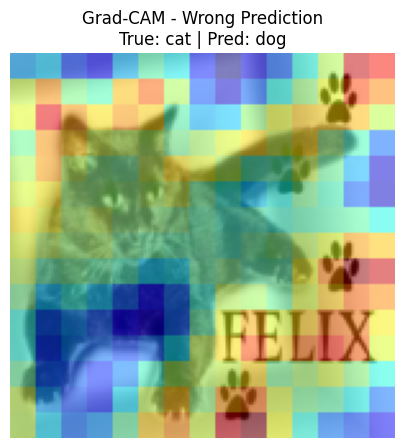

Caption: Grad-CAM shows the model focused on regions that were not distinctive enough to correctly identify the cat, leading to a dog prediction.


In [39]:
wrong_img, wrong_label, wrong_pred = wrong_examples[0]

wrong_img = wrong_img.to(DEVICE)

cam_attr = gradcam.attribute(
    wrong_img,
    target=None
)

upsampled_cam = LayerAttribution.interpolate(
    cam_attr,
    (150,150)
)

cam = upsampled_cam.squeeze().detach().cpu().numpy()

img_np = wrong_img.detach().cpu().squeeze(0).permute(1,2,0).numpy()
img_np = (img_np * 0.5) + 0.5
img_np = np.clip(img_np, 0, 1)

plt.figure(figsize=(5,5))
plt.imshow(img_np)
plt.imshow(cam, cmap="jet", alpha=0.5)
plt.axis("off")
plt.title(
    f"Grad-CAM - Wrong Prediction\n"
    f"True: {'dog' if wrong_label==1 else 'cat'} | "
    f"Pred: {'dog' if wrong_pred==1 else 'cat'}"
)
plt.show()

print("Caption: Grad-CAM shows the model focused on regions that were not distinctive enough to correctly identify the cat, leading to a dog prediction.")

The CNN incorrectly classified this cat image as a dog. The Grad-CAM heatmap shows that the model focused on visual features that were confusing, possibly including the background, fur patterns, or shape features that overlap between cats and dogs.

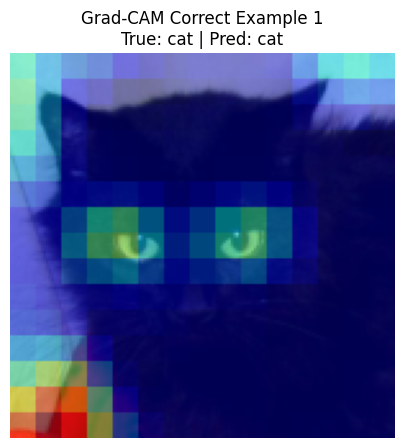

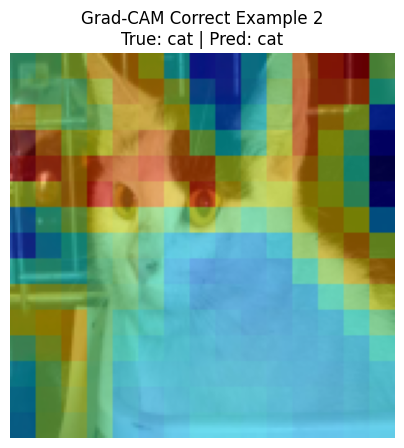

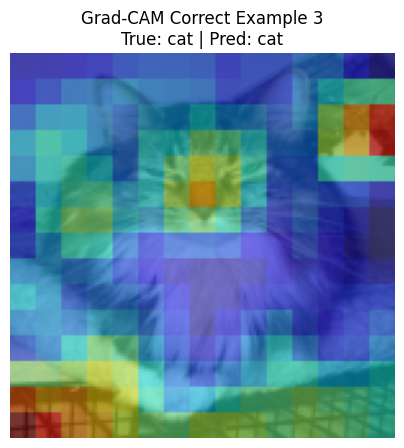

Caption: Grad-CAM highlights that the model mainly attended to the animal's face and upper body when making its prediction.


In [36]:
for i, example in enumerate(correct_examples):

    img, label, pred = example
    img = img.to(DEVICE)

    cam_attr = gradcam.attribute(
        img,
        target=None
    )

    upsampled_cam = LayerAttribution.interpolate(
        cam_attr,
        (150,150)
    )

    cam = upsampled_cam.squeeze().detach().cpu().numpy()

    img_np = img.detach().cpu().squeeze(0).permute(1,2,0).numpy()
    img_np = (img_np * 0.5) + 0.5
    img_np = np.clip(img_np,0,1)

    plt.figure(figsize=(5,5))
    plt.imshow(img_np)
    plt.imshow(cam, cmap="jet", alpha=0.5)
    plt.axis("off")
    plt.title(
        f"Grad-CAM Correct Example {i+1}\n"
        f"True: {'dog' if label==1 else 'cat'} | "
        f"Pred: {'dog' if pred==1 else 'cat'}"
    )
    plt.show()
print("Caption: Grad-CAM highlights that the model mainly attended to the animal's face and upper body when making its prediction.")

The Grad-CAM results for correctly classified images show that the model generally focused on important regions of the animals, such as the face, ears, and body shape. Compared with the incorrect prediction, the model appeared to use more relevant animal features when making correct decisions.

In [16]:
wrong_img, wrong_label, wrong_pred = wrong_examples[0]

wrong_img = wrong_img.to(DEVICE)

print("True label:", wrong_label)
print("Predicted:", wrong_pred)

True label: 0
Predicted: 1


In [17]:
wrong_cam_attr = gradcam.attribute(
    wrong_img
)

print(wrong_cam_attr.shape)

torch.Size([1, 1, 15, 15])


In [18]:
wrong_upsampled_cam = LayerAttribution.interpolate(
    wrong_cam_attr,
    (IMG_SIZE, IMG_SIZE)
)

wrong_cam = wrong_upsampled_cam.squeeze().detach().numpy()

print(wrong_cam.shape)

(150, 150)


In [19]:
wrong_img_np = wrong_img.squeeze().permute(1,2,0).detach().numpy()

wrong_img_np = (wrong_img_np * 0.5) + 0.5
wrong_img_np = np.clip(wrong_img_np, 0, 1)

print(wrong_img_np.shape)

(150, 150, 3)


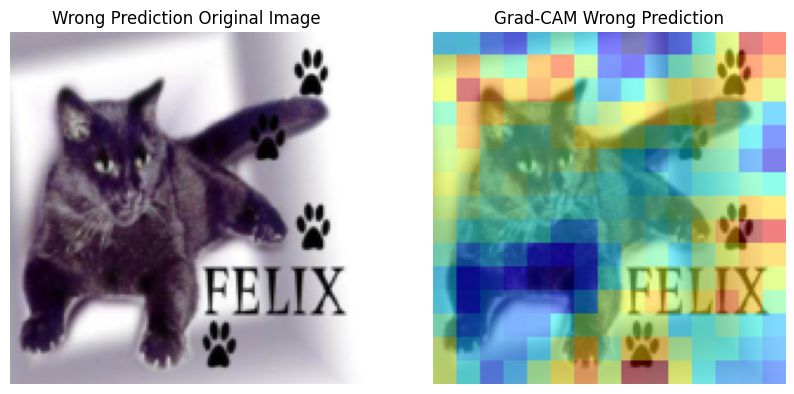

In [20]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(wrong_img_np)
plt.title("Wrong Prediction Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(wrong_img_np)
plt.imshow(wrong_cam, cmap="jet", alpha=0.5)
plt.title("Grad-CAM Wrong Prediction")
plt.axis("off")

plt.savefig(
    "gradcam_wrong_prediction.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

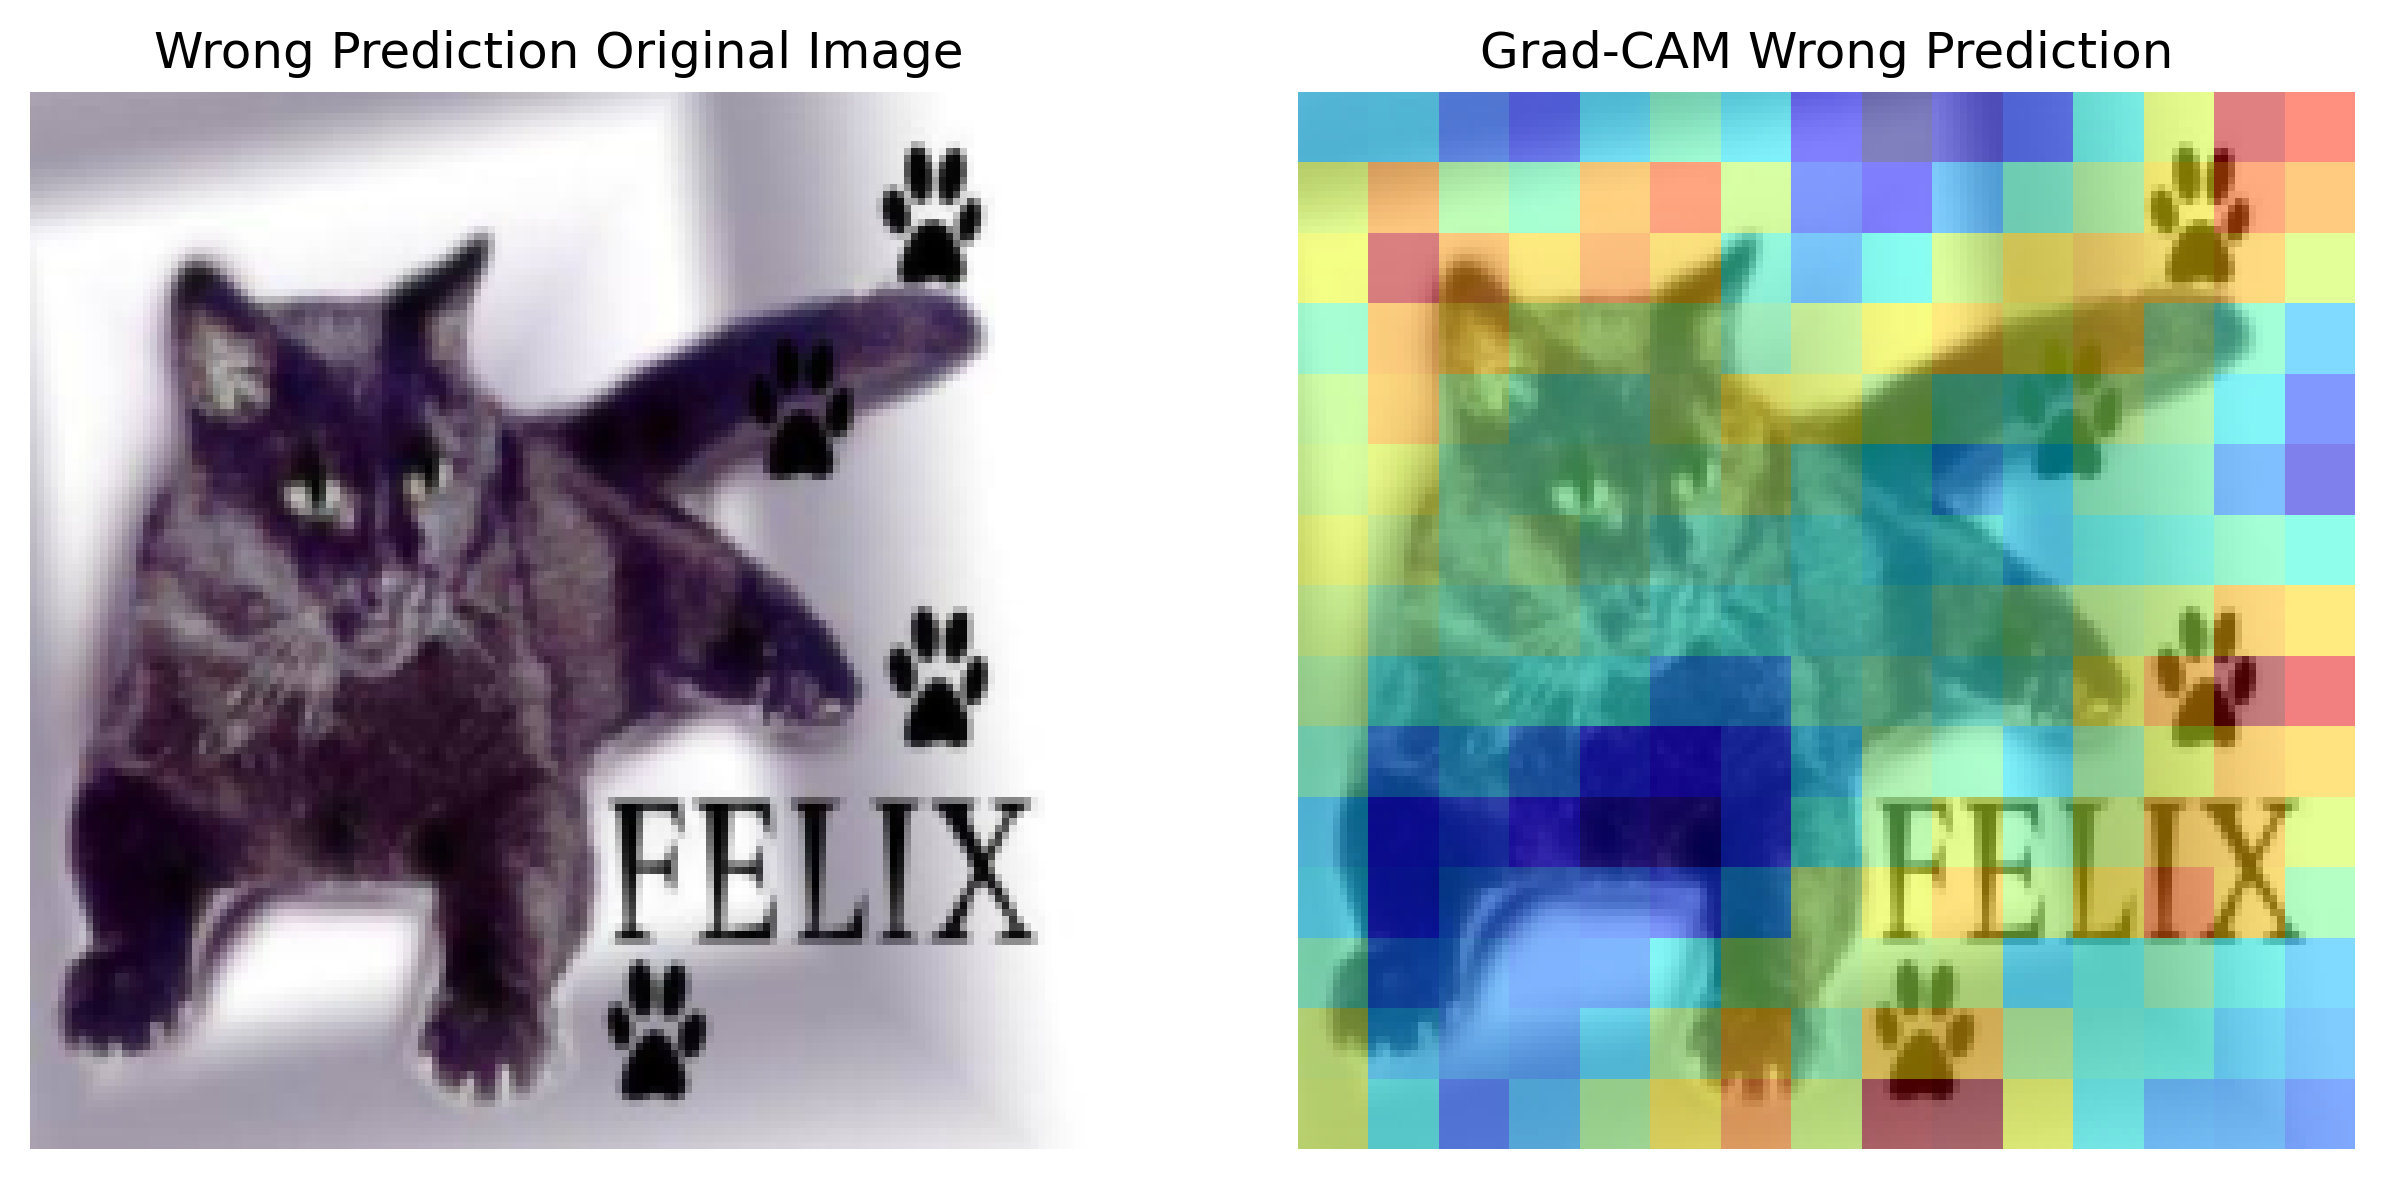

In [21]:
from IPython.display import Image

Image("gradcam_wrong_prediction.png")

## Interpretation of Results

Integrated Gradients and Grad-CAM both identified important regions that influenced the model's predictions. In the correctly classified images, both methods mainly highlighted the animal's face and body, suggesting these features were most useful for classification.

The two methods provide different types of explanations. Integrated Gradients gives detailed pixel-level importance, while Grad-CAM produces a broader heatmap showing where the network focused in the image.

For the misclassified example, both methods indicate that the model attended to visual features that were not distinctive enough to separate the cat from a dog. This suggests the model learned some confusing visual patterns instead of relying only on the most discriminative features.

Overall, using both methods together provides a better understanding of how the CNN makes its predictions and why mistakes can occur.